# Lab thực hành: Mạng thần kinh để nhận dạng chữ số viết tay, nhiều lớp 

Trong bài tập này, bạn sẽ sử dụng neural network để nhận dạng các chữ số viết tay từ 0-9.


# Phác thảo
- [ 1 - Packages ](#1)
- [ 2 - ReLU Activation](#2)
- [ 3 - Softmax Function](#3)
  - [ Exercise 1](#ex01)
- [ 4 - Neural Networks](#4)
  - [ 4.1 Problem Statement](#4.1)
  - [ 4.2 Dataset](#4.2)
  - [ 4.3 Model representation](#4.3)
  - [ 4.4 Tensorflow Model Implementation](#4.4)
  - [ 4.5 Softmax placement](#4.5)
    - [ Exercise 2](#ex02)


<a name="1"></a>
## 1 - Package 

Trước tiên, hãy chạy ô bên dưới để nhập tất cả các gói mà bạn sẽ cần trong nhiệm vụ này.
- [numpy](https://numpy.org/) là gói cơ bản dành cho máy tính khoa học với Python.
- [matplotlib](http://matplotlib.org) là thư viện phổ biến để vẽ đồ thị trong Python.
- [tensorflow](https://www.tensorflow.org/) một nền tảng phổ biến cho học máy.


In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.activations import linear, relu, sigmoid
%matplotlib widget
import matplotlib.pyplot as plt
plt.style.use('./deeplearning.mplstyle')

import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
tf.autograph.set_verbosity(0)

from public_tests import * 

from autils import *
from lab_utils_softmax import plt_softmax
np.set_printoptions(precision=2)

2026-06-22 13:47:20.840973: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-22 13:47:20.875393: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-06-22 13:47:20.876025: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-22 13:47:21.515152: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


<a name="2"></a>
## 2 - ReLU Kích hoạt
Tuần này, một kích hoạt mới đã được giới thiệu, Đơn vị tuyến tính chỉnh lưu (ReLU). 
$$ a = max(0,z)$$


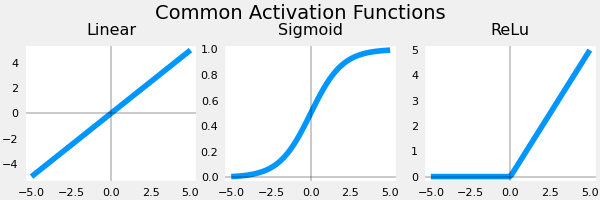

In [2]:
plt_act_trio()

<img align="right" src="./images/C2_W2_ReLu.png"     style=" width:380px; padding: 10px 20px; " >
Ví dụ từ bài giảng bên phải cho thấy ứng dụng của ReLU. Trong ví dụ này, feature "nhận thức" dẫn xuất không phải là nhị phân mà có phạm vi giá trị liên tục. sigmoid là tốt nhất cho các tình huống bật/tắt hoặc nhị phân. ReLU cung cấp mối quan hệ tuyến tính liên tục. Ngoài ra, nó có phạm vi 'tắt' trong đó đầu ra bằng 0.     
feature "tắt" làm cho ReLU kích hoạt Phi tuyến tính. Tại sao điều này lại cần thiết? Điều này cho phép nhiều đơn vị đóng góp vào chức năng kết quả mà không can thiệp. Điều này sẽ được kiểm tra nhiều hơn trong Lab hỗ trợ.


<a name="3"></a>
## 3 - Chức năng Softmax
Một đa lớp neural network tạo ra N đầu ra. Một đầu ra được chọn làm câu trả lời dự đoán. Trong lớp đầu ra, vectơ $\mathbf{z}$ được tạo bởi hàm tuyến tính được đưa vào hàm softmax. Hàm softmax chuyển đổi $\mathbf{z}$ thành phân bố xác suất như mô tả bên dưới. Sau khi áp dụng softmax, mỗi đầu ra sẽ nằm trong khoảng từ 0 đến 1 và tổng các đầu ra sẽ bằng 1. Chúng có thể được hiểu là xác suất. Đầu vào lớn hơn cho softmax sẽ tương ứng với xác suất đầu ra lớn hơn.
<center> <img  src="./images/C2_W2_NNSoftmax.PNG" width="600" />


Hàm softmax có thể được viết:
$$a_j = \frac{e^{z_j}}{ \sum_{k=0}^{N-1}{e^{z_k} }} \tag{1}$$

Trong đó $z = \mathbf{w} \cdot \mathbf{x} + b$ và N là số feature/danh mục trong lớp đầu ra.


<a name="ex01"></a>
### Bài tập 1
Hãy tạo một triển khai NumPy:


In [ ]:
# UNQ_C1
# GRADED CELL: my_softmax

def my_softmax(z):  
    """ Softmax converts a vector of values to a probability distribution.
    Args:
      z (ndarray (N,))  : input data, N features
    Returns:
      a (ndarray (N,))  : softmax of z
    """    
    # ## BẮT ĐẦU MÃ TẠI ĐÂY ###
    ez = np.exp(z)
    a = ez / np.sum(ez)
    # ## KẾT THÚC MÃ TẠI ĐÂY ###
    return a

In [8]:
z = np.array([1., 2., 3., 4.])
a = my_softmax(z)
atf = tf.nn.softmax(z)
print(f"my_softmax(z):         {a}")
print(f"tensorflow softmax(z): {atf}")

# BẮT ĐẦU KIỂM TRA ĐƠN VỊ
test_my_softmax(my_softmax)
# KẾT THÚC ĐƠN VỊ KIỂM TRA

my_softmax(z):         [0.03 0.09 0.24 0.64]
tensorflow softmax(z): [0.03 0.09 0.24 0.64]
 All tests passed.


<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để xem gợi ý</b></font></summary>
    Một cách triển khai sử dụng vòng lặp for để xây dựng mẫu số trước tiên và sau đó là vòng lặp thứ hai để tính toán từng đầu ra.
    
```python
def my_softmax(z):  
    N = len(z)
    a =                     # initialize a to zeros 
    ez_sum =                # initialize sum to zero
    for k in range(N):      # loop over number of outputs             
        ez_sum +=           # sum exp(z[k]) to build the shared denominator      
    for j in range(N):      # loop over number of outputs again                
        a[j] =              # divide each the exp of each output by the denominator   
    return(a)
```
<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để lấy mã</b></font></summary>
   
```python
def my_softmax(z):  
    N = len(z)
    a = np.zeros(N)
    ez_sum = 0
    for k in range(N):                
        ez_sum += np.exp(z[k])       
    for j in range(N):                
        a[j] = np.exp(z[j])/ez_sum   
    return(a)

Or, a vector implementation:

def my_softmax(z):  
    ez = np.exp(z)              
    a = ez/np.sum(ez)           
    return(a)

```


Dưới đây, hãy thay đổi giá trị của đầu vào `z`. Đặc biệt lưu ý cách số mũ trong tử số phóng to những khác biệt nhỏ trong các giá trị. Cũng lưu ý rằng tổng các giá trị đầu ra là một.


In [9]:
plt.close("all")
plt_softmax(my_softmax)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

<a name="4"></a>
## 4 - Mạng nơ-ron

Trong bài tập tuần trước, bạn đã triển khai neural network để thực hiện phân loại nhị phân. Tuần này bạn sẽ mở rộng điều đó sang phân loại nhiều lớp. Điều này sẽ sử dụng kích hoạt softmax.


<a name="4.1"></a>
### 4.1 Bài toán

Trong bài tập này, bạn sẽ sử dụng neural network để nhận dạng mười chữ số viết tay, 0-9. Đây là một nhiệm vụ phân loại nhiều lớp trong đó một trong n lựa chọn được chọn. Nhận dạng chữ số viết tay tự động được sử dụng rộng rãi ngày nay - từ nhận dạng mã zip (mã bưu chính) trên phong bì thư đến nhận dạng số tiền viết trên séc ngân hàng. 


<a name="4.2"></a>
### 4.2 Bộ dữ liệu

Bạn sẽ bắt đầu bằng cách tải tập dữ liệu cho tác vụ này. 
- Hàm `load_data()` hiển thị bên dưới tải dữ liệu vào các biến `X` và `y`


- Bộ dữ liệu chứa 5000 training example về chữ số viết tay $^1$.  

    - Mỗi training example là một ảnh thang độ xám 20 pixel x 20 pixel của chữ số. 
        - Mỗi pixel được biểu thị bằng một số dấu phẩy động cho biết cường độ thang độ xám tại vị trí đó. 
        - Lưới 20 x 20 pixel được “trải” thành một vectơ 400 chiều. 
        - Mỗi traning example trở thành một hàng duy nhất trong ma trận dữ liệu của chúng ta `X`. 
        - Điều này mang lại cho chúng ta một ma trận 5000 x 400 `X` trong đó mỗi hàng là một traning example về hình ảnh chữ số viết tay.

$$X = 
\left(\begin{array}{cc} 
--- (x^{(1)}) --- \\
--- (x^{(2)}) --- \\
\vdots \\ 
--- (x^{(m)}) --- 
\end{array}\right)$$ 

- Phần thứ hai của tập training là vectơ 5000 x 1 chiều `y` chứa các nhãn cho tập training
    - `y = 0` nếu hình ảnh là chữ số `0`, `y = 4` nếu hình ảnh là chữ số `4`, v.v.

$^1$<sub> Đây là tập hợp con của tập dữ liệu chữ số viết tay MNIST (http://yann.lecun.com/exdb/mnist/)</sub>


In [10]:
# tải tập dữ liệu
X, y = load_data()

#### 4.2.1 Xem các biến
Hãy làm quen nhiều hơn với tập dữ liệu của bạn.  
- Cách tốt nhất để bắt đầu là in ra từng biến và xem nó chứa gì.

Đoạn mã bên dưới in phần tử đầu tiên trong các biến `X` và `y`.


In [ ]:
print ('The first element of X is: ', X[0])

In [11]:
print ('The first element of y is: ', y[0,0])
print ('The last element of y is: ', y[-1,0])

The first element of y is:  0
The last element of y is:  9


#### 4.2.2 Kiểm tra chiều của các biến của bạn

Một cách khác để làm quen với dữ liệu của bạn là xem kích thước của nó. Vui lòng in hình dạng `X` và `y` và xem bạn có bao nhiêu traning example trong tập dữ liệu của mình.


In [12]:
print ('The shape of X is: ' + str(X.shape))
print ('The shape of y is: ' + str(y.shape))

The shape of X is: (5000, 400)
The shape of y is: (5000, 1)


#### 4.2.3 Trực quan hóa dữ liệu

Bạn sẽ bắt đầu bằng cách hình dung một tập con của tập training. 
- Trong ô bên dưới, mã chọn ngẫu nhiên 64 hàng từ `X`, ánh xạ mỗi hàng trở lại hình ảnh thang độ xám 20 pixel x 20 pixel và hiển thị các hình ảnh cùng nhau. 
- Nhãn cho mỗi hình ảnh được hiển thị phía trên hình ảnh


In [13]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Bạn không cần sửa đổi bất cứ điều gì trong ô này

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]

# fig.tight_layout(pad=0.5)
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Chọn chỉ số ngẫu nhiên
    random_index = np.random.randint(m)
    
    # Chọn các hàng tương ứng với các chỉ số ngẫu nhiên và
    # định hình lại hình ảnh
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Hiển thị hình ảnh
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Hiển thị nhãn phía trên hình ảnh
    ax.set_title(y[random_index,0])
    ax.set_axis_off()
    fig.suptitle("Label, image", fontsize=14)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

<a name="4.3"></a>
### 4.3 Biểu diễn mô hình

neural network bạn sẽ sử dụng trong bài tập này được hiển thị trong hình bên dưới. 
- Lớp này có hai lớp dày đặc với kích hoạt ReLU, sau đó là lớp đầu ra với kích hoạt tuyến tính. 
    - Hãy nhớ lại rằng đầu vào của chúng ta là giá trị pixel của hình ảnh chữ số.
    - Vì hình ảnh có kích thước $20\times20$, điều này mang lại cho chúng ta đầu vào $400$  
    
<img src="images/C2_W2_Assigment_NN.png" width="600" height="450">


- Các tham số có kích thước có kích thước cho neural network với đơn vị $25$ ở lớp 1, $15$ đơn vị ở lớp 2 và $10$ đơn vị đầu ra ở lớp 3, một đơn vị cho mỗi chữ số.

    - Nhắc lại kích thước của các tham số này được xác định như sau:
        - Nếu mạng có $s_{in}$ đơn vị trong một lớp và $s_{out}$ đơn vị ở lớp tiếp theo thì 
            - $W$ sẽ có kích thước $s_{in} \times s_{out}$.
            - $b$ sẽ là một vectơ có phần tử $s_{out}$
  
    - Do đó, hình dạng của `W` và `b` là 
        - layer1: Hình dạng của `W1` là (400, 25) và hình dạng của `b1` là (25,)
        - layer2: Hình dạng của `W2` là (25, 15) và hình dạng của `b2` là: (15,)
        - layer3: Hình dạng của `W3` là (15, 10) và hình dạng của `b3` là: (10,)
>**Lưu ý:** Vectơ thiên vị `b` có thể được biểu diễn dưới dạng mảng 1-D (n,) hoặc 2-D (n,1). Tensorflow sử dụng biểu diễn 1-D và Lab này sẽ duy trì quy ước đó:


<a name="4.4"></a>
### 4.4 Triển khai mô hình Tensorflow


Các mô hình Tensorflow được xây dựng từng lớp. Kích thước đầu vào của lớp ($s_{in}$ ở trên) được tính cho bạn. Bạn chỉ định *kích thước đầu ra* của một lớp và điều này sẽ xác định kích thước đầu vào của lớp tiếp theo. Kích thước đầu vào của lớp đầu tiên được lấy từ kích thước của dữ liệu đầu vào được chỉ định trong câu lệnh `model.fit` bên dưới. 
>**Lưu ý:** Cũng có thể thêm lớp đầu vào để chỉ định kích thước đầu vào của lớp đầu tiên. Ví dụ:  
`tf.keras.Input(shape=(400,)),    #specify input shape`  
chúng ta sẽ đưa điều đó vào đây để làm sáng tỏ một số kích thước mô hình.


<a name="4.5"></a>
### 4.5 Vị trí Softmax
Như được mô tả trong bài giảng và Lab softmax tùy chọn, độ ổn định số được cải thiện nếu softmax được nhóm với hàm loss thay vì lớp đầu ra trong quá trình training. Điều này có ý nghĩa khi *xây dựng* mô hình và *sử dụng* mô hình.  
Tòa nhà:  
* Lớp dày đặc cuối cùng nên sử dụng kích hoạt 'tuyến tính'. Điều này thực sự không có kích hoạt. 
* Câu lệnh `model.compile` sẽ chỉ ra điều này bằng cách bao gồm `from_logits=True`.
`loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) `  
* Điều này không ảnh hưởng đến hình thức của target. Trong trường hợp SparseCategorialCrossentropy, target là chữ số dự kiến, 0-9.

Sử dụng mô hình:
* Kết quả đầu ra không phải là xác suất. Nếu muốn xác suất đầu ra, hãy áp dụng hàm softmax.


<a name="ex02"></a>
### Bài tập 2

Dưới đây, sử dụng Keras [Sequential model](https://keras.io/guides/sequential_model/) và [Dense Layer](https://keras.io/api/layers/core_layers/dense/) với kích hoạt ReLU để xây dựng mạng ba lớp được mô tả ở trên.


In [16]:
# UNQ_C2
# GRADED CELL: Sequential model
tf.random.set_seed(1234) # for consistent results
model = Sequential(
    [               
        # ## BẮT ĐẦU MÃ TẠI ĐÂY ###
        tf.keras.layers.InputLayer((400,)),
        tf.keras.layers.Dense(25, activation="relu", name="L1"),
        tf.keras.layers.Dense(15, activation="relu", name="L2"),
        tf.keras.layers.Dense(10, activation="linear", name="L3")
        # ## KẾT THÚC MÃ TẠI ĐÂY ###
    ], name = "my_model" 
)
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))

In [17]:
model.summary()

Model: "my_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 L1 (Dense)                  (None, 25)                10025     
                                                                 
 L2 (Dense)                  (None, 15)                390       
                                                                 
 L3 (Dense)                  (None, 10)                160       
                                                                 
Total params: 10,575
Trainable params: 10,575
Non-trainable params: 0
_________________________________________________________________


<details>
  <summary><font size="3" color="darkgreen"><b>Đầu ra dự kiến (Nhấp để mở rộng)</b></font></summary>
Hàm `model.summary()` hiển thị bản tóm tắt hữu ích của mô hình. Lưu ý, tên của các lớp có thể khác nhau vì chúng được tạo tự động trừ khi tên được chỉ định.    
    
```
Model: "my_model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
=================================================================
L1 (Dense)                   (None, 25)                10025     
_________________________________________________________________
L2 (Dense)                   (None, 15)                390       
_________________________________________________________________
L3 (Dense)                   (None, 10)                160       
=================================================================
Total params: 10,575
Trainable params: 10,575
Non-trainable params: 0
_________________________________________________________________
```


<details>
  <summary><font size="3" color="darkgreen"><b>Nhấp để xem gợi ý</b></font></summary>
    
```python
tf.random.set_seed(1234)
model = Sequential(
    [               
        ### START CODE HERE ### 
        tf.keras.Input(shape=(400,)),     # @REPLACE 
        Dense(25, activation='relu', name = "L1"), # @REPLACE 
        Dense(15, activation='relu',  name = "L2"), # @REPLACE  
        Dense(10, activation='linear', name = "L3"),  # @REPLACE 
        ### END CODE HERE ### 
    ], name = "my_model" 
)
```


In [18]:
# BẮT ĐẦU KIỂM TRA ĐƠN VỊ
test_model(model, 10, 400)
# KẾT THÚC ĐƠN VỊ KIỂM TRA

All tests passed!


Số lượng tham số hiển thị trong bản tóm tắt tương ứng với số phần tử trong mảng trọng số và độ lệch như hình dưới đây.


Chúng ta hãy kiểm tra thêm các trọng số để xác minh rằng tensorflow tạo ra các kích thước giống như chúng ta đã tính toán ở trên.


In [19]:
[layer1, layer2, layer3] = model.layers

In [20]:
# ### Kiểm tra hình dạng của Trọng lượng
W1,b1 = layer1.get_weights()
W2,b2 = layer2.get_weights()
W3,b3 = layer3.get_weights()
print(f"W1 shape = {W1.shape}, b1 shape = {b1.shape}")
print(f"W2 shape = {W2.shape}, b2 shape = {b2.shape}")
print(f"W3 shape = {W3.shape}, b3 shape = {b3.shape}")

W1 shape = (400, 25), b1 shape = (25,)
W2 shape = (25, 15), b2 shape = (15,)
W3 shape = (15, 10), b3 shape = (10,)


**Đầu ra dự kiến**
```
W1 shape = (400, 25), b1 shape = (25,)  
W2 shape = (25, 15), b2 shape = (15,)  
W3 shape = (15, 10), b3 shape = (10,)
```


Đoạn mã sau:
* xác định hàm tổn thất, `SparseCategoricalCrossentropy` và cho biết softmax nên được đưa vào tính toán tổn thất bằng cách thêm `from_logits=True`)
* định nghĩa một trình tối ưu hóa. Một lựa chọn phổ biến là Thời điểm thích ứng (Adam) đã được mô tả trong bài giảng.


In [21]:
model.compile(
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
)

history = model.fit(
    X,y,
    epochs=40
)

Epoch 1/40
157/157 [==============================] - 1s 2ms/step - loss: 1.7094
Epoch 2/40
157/157 [==============================] - 0s 2ms/step - loss: 0.7480
Epoch 3/40
157/157 [==============================] - 0s 2ms/step - loss: 0.4428
Epoch 4/40
157/157 [==============================] - 0s 2ms/step - loss: 0.3463
Epoch 5/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2977
Epoch 6/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2630
Epoch 7/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2361
Epoch 8/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2131
Epoch 9/40
157/157 [==============================] - 0s 2ms/step - loss: 0.2004
Epoch 10/40
157/157 [==============================] - 0s 2ms/step - loss: 0.1805
Epoch 11/40
157/157 [==============================] - 0s 2ms/step - loss: 0.1692
Epoch 12/40
157/157 [==============================] - 0s 2ms/step - loss: 0.1580
Epoch 13/40
157/157 [====

#### epoch và đợt
Trong câu lệnh `compile` ở trên, số `epochs` được đặt thành 100. Điều này chỉ rõ rằng toàn bộ tập dữ liệu phải được áp dụng trong quá trình training 100 lần.  Trong quá trình training, bạn sẽ thấy kết quả mô tả tiến trình training như thế này:
```
Epoch 1/100
157/157 [==============================] - 0s 1ms/step - loss: 2.2770
```
Dòng đầu tiên, `Epoch 1/100`, mô tả epoch mà mô hình hiện đang chạy. Để đạt hiệu quả, tập dữ liệu training được chia thành các 'đợt'. Kích thước mặc định của một lô trong Tensorflow là 32. Có 5000 ví dụ trong tập dữ liệu của chúng ta hoặc khoảng 157 lô. Ký hiệu ở dòng thứ 2 `157/157 [====` mô tả lô nào đã được thực thi.


#### Mất mát (cost)
Trong khóa 1, chúng ta đã học cách theo dõi tiến trình của gradient descent bằng cách theo dõi cost. Lý tưởng nhất là cost sẽ giảm khi số lần lặp của thuật toán tăng lên. Tensorflow đề cập đến cost là `loss`. Ở trên, bạn thấy phần mất hiển thị ở mỗi epoch khi `model.fit` đang thực thi. Phương thức [.fit](https://www.tensorflow.org/api_docs/python/tf/keras/Model) trả về nhiều số liệu khác nhau bao gồm cả tổn thất. Điều này được ghi lại trong biến `history` ở trên. Điều này có thể được sử dụng để kiểm tra sự mất mát trong một biểu đồ như dưới đây.


In [22]:
plot_loss_tf(history)

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

#### Dự đoán 
Để đưa ra dự đoán, hãy sử dụng Keras `predict`. Bên dưới, X[1015] chứa hình ảnh của hai.


In [23]:
image_of_two = X[1015]
display_digit(image_of_two)

prediction = model.predict(image_of_two.reshape(1,400))  # prediction

print(f" predicting a Two: \n{prediction}")
print(f" Largest Prediction index: {np.argmax(prediction)}")

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

 predicting a Two: 
[[ -7.99  -2.23   0.77  -2.41 -11.66 -11.15  -9.53  -3.36  -4.42  -7.17]]
 Largest Prediction index: 2


Đầu ra lớn nhất là dự đoán[2], cho biết chữ số được dự đoán là '2'. Nếu bài toán chỉ yêu cầu một lựa chọn thì thế là đủ. Sử dụng NumPy [argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html) để chọn nó. Nếu bài toán yêu cầu xác suất thì bắt buộc phải có softmax:


In [24]:
prediction_p = tf.nn.softmax(prediction)

print(f" predicting a Two. Probability vector: \n{prediction_p}")
print(f"Total of predictions: {np.sum(prediction_p):0.3f}")

 predicting a Two. Probability vector: 
[[1.42e-04 4.49e-02 8.98e-01 3.76e-02 3.61e-06 5.97e-06 3.03e-05 1.44e-02
  5.03e-03 3.22e-04]]
Total of predictions: 1.000


Để trả về một số nguyên đại diện cho target dự đoán, bạn muốn chỉ số có xác suất lớn nhất. Điều này được thực hiện bằng hàm Numpy [argmax](https://numpy.org/doc/stable/reference/generated/numpy.argmax.html).


In [25]:
yhat = np.argmax(prediction_p)

print(f"np.argmax(prediction_p): {yhat}")

np.argmax(prediction_p): 2


Hãy so sánh dự đoán với nhãn cho một mẫu ngẫu nhiên gồm 64 chữ số. Việc này cần một chút thời gian để chạy.


In [26]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
# Bạn không cần sửa đổi bất cứ điều gì trong ô này

m, n = X.shape

fig, axes = plt.subplots(8,8, figsize=(5,5))
fig.tight_layout(pad=0.13,rect=[0, 0.03, 1, 0.91]) #[left, bottom, right, top]
widgvis(fig)
for i,ax in enumerate(axes.flat):
    # Chọn chỉ số ngẫu nhiên
    random_index = np.random.randint(m)
    
    # Chọn các hàng tương ứng với các chỉ số ngẫu nhiên và
    # định hình lại hình ảnh
    X_random_reshaped = X[random_index].reshape((20,20)).T
    
    # Hiển thị hình ảnh
    ax.imshow(X_random_reshaped, cmap='gray')
    
    # Dự đoán bằng cách sử dụng Mạng thần kinh
    prediction = model.predict(X[random_index].reshape(1,400))
    prediction_p = tf.nn.softmax(prediction)
    yhat = np.argmax(prediction_p)
    
    # Hiển thị nhãn phía trên hình ảnh
    ax.set_title(f"{y[random_index,0]},{yhat}",fontsize=10)
    ax.set_axis_off()
fig.suptitle("Label, yhat", fontsize=14)
plt.show()

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

Chúng ta hãy xem xét một số lỗi. 
>Lưu ý: việc tăng số lượng giai đoạn training có thể loại bỏ các lỗi trên tập dữ liệu này.


In [27]:
print( f"{display_errors(model,X,y)} errors out of {len(X)} images")

Canvas(toolbar=Toolbar(toolitems=[('Home', 'Reset original view', 'home', 'home'), ('Back', 'Back to previous …

15 errors out of 5000 images


### Chúc mừng!
Bạn đã xây dựng và sử dụng thành công neural network để phân loại nhiều lớp.
